# Jaguar Re-Identification Challenge - Exploratory Data Analysis (EDA)

In [1]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from PIL import Image

DATA_DIR = os.path.join('..', 'data')
TRAIN_IMG_DIR = os.path.join(DATA_DIR, 'train', 'train')
TEST_IMG_DIR = os.path.join(DATA_DIR, 'test', 'test')

## 1. Loading CSV files

In [2]:
train_df = pd.read_csv(os.path.join(DATA_DIR, 'train.csv'))
test_df = pd.read_csv(os.path.join(DATA_DIR, 'test.csv'))
sample_sub = pd.read_csv(os.path.join(DATA_DIR, 'sample_submission.csv'))

print(f"Train: {train_df.shape[0]} rows, columns: {list(train_df.columns)}")
print(f"Test:  {test_df.shape[0]} rows, columns: {list(test_df.columns)}")
print(f"Sample submission: {sample_sub.shape[0]} rows, columns: {list(sample_sub.columns)}")

Train: 1895 rows, columns: ['filename', 'ground_truth']
Test:  137270 rows, columns: ['row_id', 'query_image', 'gallery_image']
Sample submission: 137270 rows, columns: ['row_id', 'similarity']


In [3]:
print("=== train.csv ===")
display(train_df.head(10))
print("\n=== test.csv ===")
display(test_df.head(10))
print("\n=== sample_submission.csv ===")
display(sample_sub.head(10))

=== train.csv ===


,filename,ground_truth
0,train_0001.png,Abril
1,train_0002.png,Abril
2,train_0003.png,Abril
3,train_0004.png,Akaloi
4,train_0005.png,Akaloi
5,train_0006.png,Apeiara
6,train_0007.png,Apeiara
7,train_0008.png,Apeiara
8,train_0009.png,Ariely
9,train_0010.png,Ariely



=== test.csv ===


,row_id,query_image,gallery_image
0,0,test_0001.png,test_0002.png
1,1,test_0001.png,test_0003.png
2,2,test_0001.png,test_0004.png
3,3,test_0001.png,test_0005.png
4,4,test_0001.png,test_0006.png
5,5,test_0001.png,test_0007.png
6,6,test_0001.png,test_0008.png
7,7,test_0001.png,test_0009.png
8,8,test_0001.png,test_0010.png
9,9,test_0001.png,test_0011.png



=== sample_submission.csv ===


,row_id,similarity
0,0,0.374540
1,1,0.950714
2,2,0.731994
3,3,0.598658
4,4,0.156019
5,5,0.155995
6,6,0.058084
7,7,0.866176
8,8,0.601115
9,9,0.708073


## 2. Jaguar identity distribution (train set)

In [4]:
identity_counts = train_df['ground_truth'].value_counts()

print(f"unique identities: {len(identity_counts)}")
print(f"train images: {len(train_df)}")
print(f"\nImages per identity:")
print(f"  Min:    {identity_counts.min()}")
print(f"  Max:    {identity_counts.max()}")
print(f"  Mean:   {identity_counts.mean():.1f}")
print(f"  Median: {identity_counts.median():.1f}")
print(f"\nTop 10 jaguars :")
print(identity_counts.head(10))
print(f"\Bottom 5 jaguars :")
print(identity_counts.tail(10))

unique identities: 31
train images: 1895

Images per identity:
  Min:    13
  Max:    183
  Mean:   61.1
  Median: 45.0

Top 10 jaguars :
ground_truth
Marcela     183
Ousado      179
Medrosa     170
Lua         120
Kwang       113
Kamaikua    105
Jaju        104
Benita       86
Ti           86
Saseka       79
Name: count, dtype: int64
\Bottom 5 jaguars :
ground_truth
Bororo       22
Abril        21
Apeiara      20
Patricia     19
Akaloi       19
Oxum         17
Estella      16
Pollyanna    16
Ipepo        13
Bernard      13
Name: count, dtype: int64


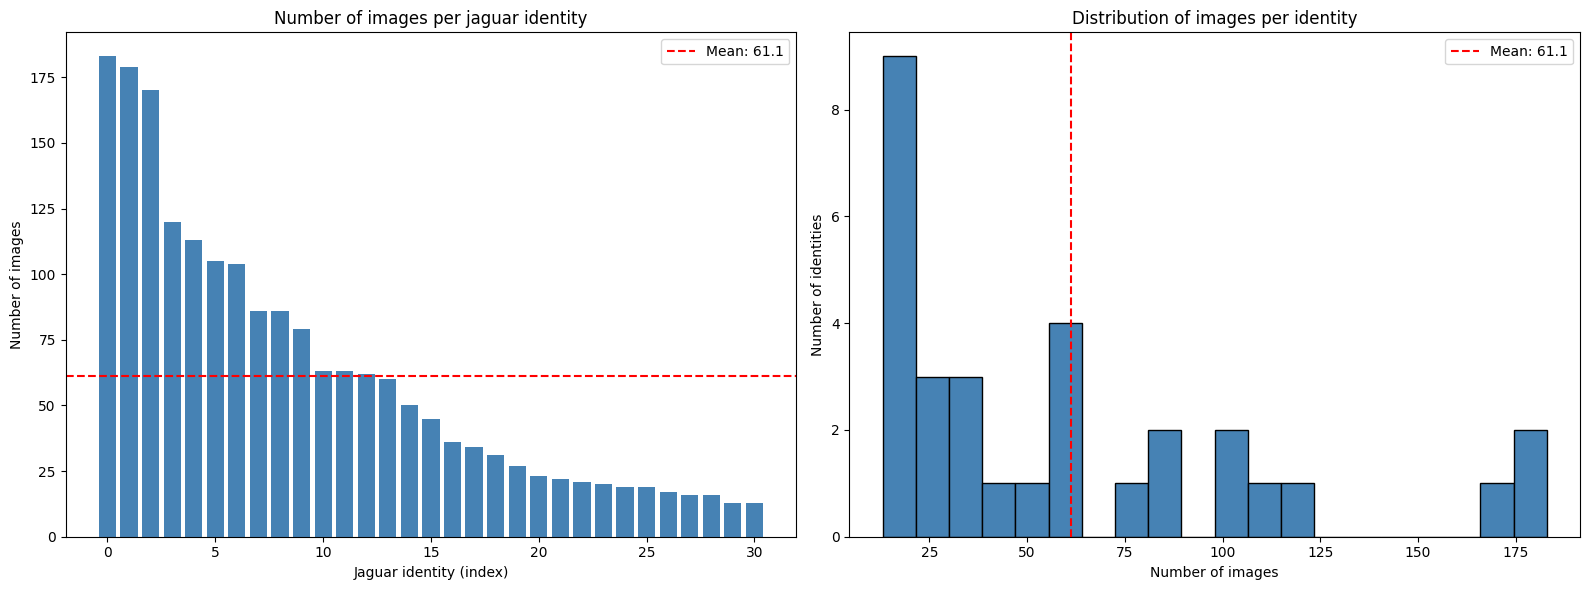

In [5]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

axes[0].bar(range(len(identity_counts)), identity_counts.values, color='steelblue')
axes[0].set_xlabel('Jaguar identity (index)')
axes[0].set_ylabel('Number of images')
axes[0].set_title('Number of images per jaguar identity')
axes[0].axhline(y=identity_counts.mean(), color='red', linestyle='--', label=f'Mean: {identity_counts.mean():.1f}')
axes[0].legend()

axes[1].hist(identity_counts.values, bins=20, color='steelblue', edgecolor='black')
axes[1].set_xlabel('Number of images')
axes[1].set_ylabel('Number of identities')
axes[1].set_title('Distribution of images per identity')
axes[1].axvline(x=identity_counts.mean(), color='red', linestyle='--', label=f'Mean: {identity_counts.mean():.1f}')
axes[1].legend()

plt.tight_layout()
plt.savefig(os.path.join('..', 'outputs', 'identity_distribution.png'), dpi=150, bbox_inches='tight')
plt.show()

## 3. Sample images per identity

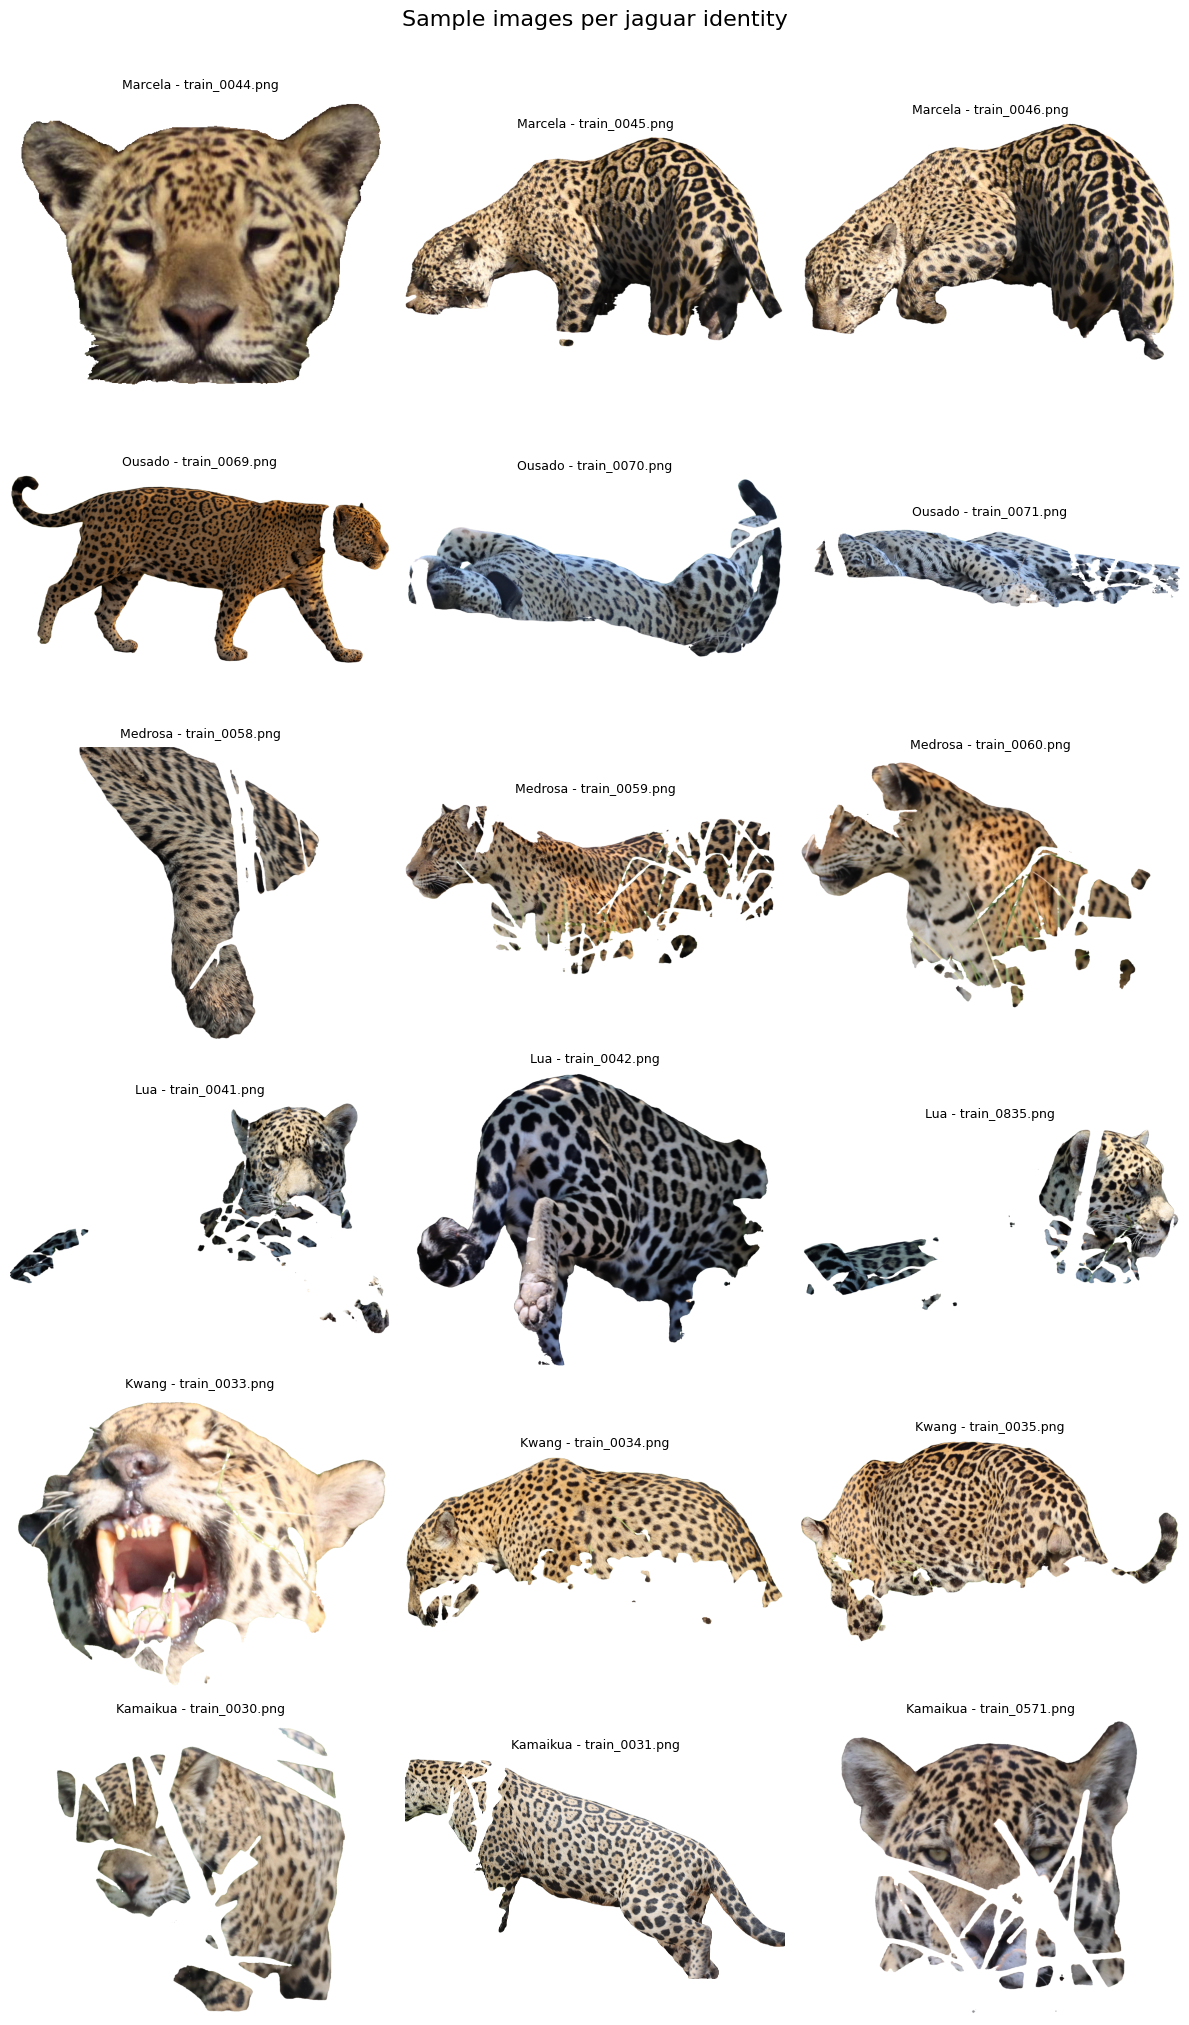

In [6]:
top_jaguars = identity_counts.head(6).index.tolist()

fig, axes = plt.subplots(6, 3, figsize=(12, 20))
fig.suptitle('Sample images per jaguar identity', fontsize=16, y=1.01)

for i, jaguar_id in enumerate(top_jaguars):
    imgs = train_df[train_df['ground_truth'] == jaguar_id]['filename'].tolist()
    for j in range(min(3, len(imgs))):
        img_path = os.path.join(TRAIN_IMG_DIR, imgs[j])
        img = Image.open(img_path)
        axes[i][j].imshow(img)
        axes[i][j].set_title(f'{jaguar_id} - {imgs[j]}', fontsize=9)
        axes[i][j].axis('off')
    for j in range(len(imgs), 3):
        axes[i][j].axis('off')

plt.tight_layout()
plt.savefig(os.path.join('..', 'outputs', 'sample_jaguars.png'), dpi=150, bbox_inches='tight')
plt.show()

## 4. Image size and resolution analysis

In [7]:
widths, heights, aspects, channels_list = [], [], [], []

for filename in train_df['filename']:
    img_path = os.path.join(TRAIN_IMG_DIR, filename)
    img = Image.open(img_path)
    w, h = img.size
    widths.append(w)
    heights.append(h)
    aspects.append(w / h)
    channels_list.append(len(img.getbands()))

print("=== Dimensions ===")
print(f"Width min: {min(widths)}, max: {max(widths)}, mean: {np.mean(widths):.0f}")
print(f"Height min: {min(heights)}, max: {max(heights)}, mean: {np.mean(heights):.0f}")
print(f"Aspect ratio min: {min(aspects):.2f}, max: {max(aspects):.2f}, mean: {np.mean(aspects):.2f}")
print(f"Channels unique: {set(channels_list)}")
print(f"Standardized size : {len(set(zip(widths, heights))) == 1}")
print(f"{len(set(zip(widths, heights)))} different sizes")

=== Dimensions ===
Width min: 308, max: 6932, mean: 3203
Height min: 247, max: 4450, mean: 2079
Aspect ratio min: 0.36, max: 9.37, mean: 1.74
Channels unique: {4}
Standardized size : False
1874 different sizes


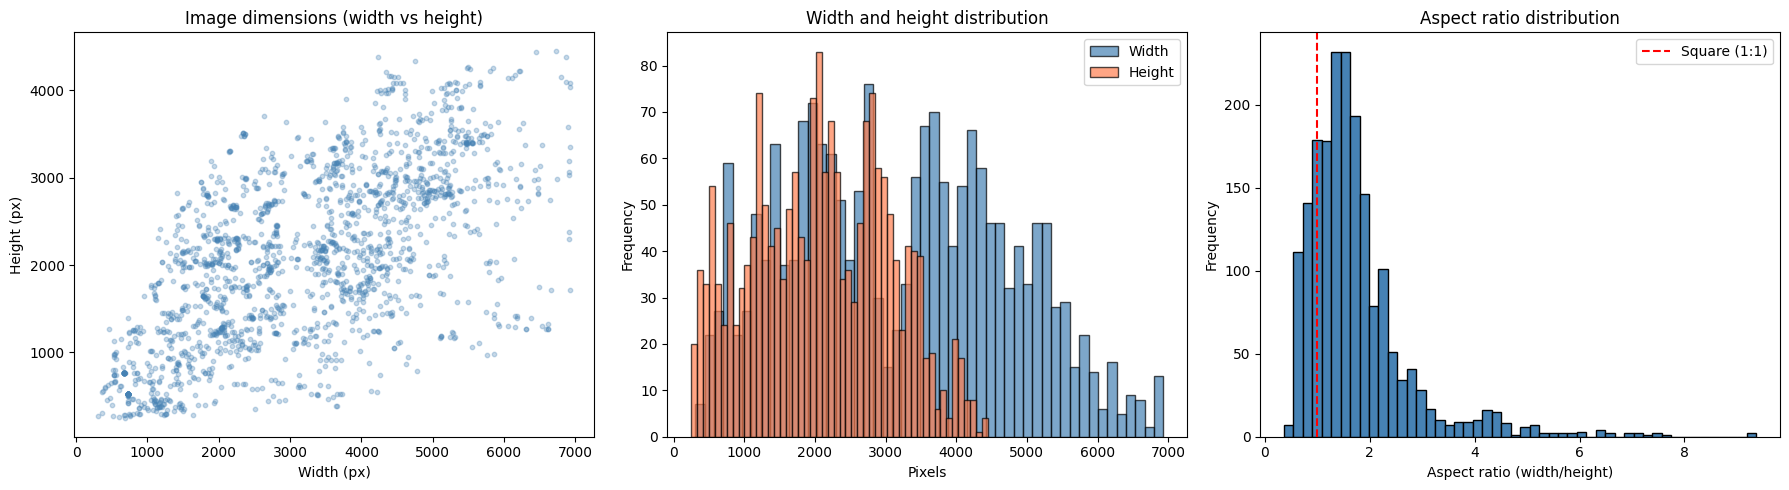

In [8]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

axes[0].scatter(widths, heights, alpha=0.3, s=10, color='steelblue')
axes[0].set_xlabel('Width (px)')
axes[0].set_ylabel('Height (px)')
axes[0].set_title('Image dimensions (width vs height)')

axes[1].hist(widths, bins=50, color='steelblue', edgecolor='black', alpha=0.7, label='Width')
axes[1].hist(heights, bins=50, color='coral', edgecolor='black', alpha=0.7, label='Height')
axes[1].set_xlabel('Pixels')
axes[1].set_ylabel('Frequency')
axes[1].set_title('Width and height distribution')
axes[1].legend()

axes[2].hist(aspects, bins=50, color='steelblue', edgecolor='black')
axes[2].set_xlabel('Aspect ratio (width/height)')
axes[2].set_ylabel('Frequency')
axes[2].set_title('Aspect ratio distribution')
axes[2].axvline(x=1.0, color='red', linestyle='--', label='Square (1:1)')
axes[2].legend()

plt.tight_layout()
plt.savefig(os.path.join('..', 'outputs', 'image_dimensions.png'), dpi=150, bbox_inches='tight')
plt.show()

In [9]:
test_files = os.listdir(TEST_IMG_DIR)
t_widths, t_heights = [], []

for filename in test_files:
    img_path = os.path.join(TEST_IMG_DIR, filename)
    img = Image.open(img_path)
    w, h = img.size
    t_widths.append(w)
    t_heights.append(h)

print("=== Dimensions ===")
print(f"Number of test images: {len(test_files)}")
print(f"Width min: {min(t_widths)}, max: {max(t_widths)}, mean: {np.mean(t_widths):.0f}")
print(f"Height min: {min(t_heights)}, max: {max(t_heights)}, mean: {np.mean(t_heights):.0f}")
print(f"Aspect ratio min: {min(aspects):.2f}, max: {max(aspects):.2f}, mean: {np.mean(aspects):.2f}")
print(f"Channels unique: {set(channels_list)}")
print(f"Standardized size : {len(set(zip(t_widths, t_heights))) == 1}")
print(f"{len(set(zip(t_widths, t_heights)))} different sizes")

=== Dimensions ===
Number of test images: 371
Width min: 193, max: 6912, mean: 3179
Height min: 176, max: 4616, mean: 1991
Aspect ratio min: 0.36, max: 9.37, mean: 1.74
Channels unique: {4}
Standardized size : False
371 different sizes
